# 스트리밍 알고리즘 2종 구현 및 정확도·메모리 트레이드오프 분석
## Bloom Filter & Count-Min Sketch


## 0. 라이브러리 설치

In [23]:
!pip install mmh3 bitarray pympler -q

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

---
## STEP 01. 데이터 준비




In [25]:
import urllib.request
import zipfile
import os

DATA_DIR = "ml-1m"
ZIP_PATH = "ml-1m.zip"
URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"

if not os.path.exists(DATA_DIR):
    print("MovieLens 1M 다운로드 중...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")
    print("다운로드 및 압축 해제 완료")
else:
    print("이미 다운로드됨")

RATINGS_PATH = os.path.join(DATA_DIR, "ratings.dat")
print("파일 경로:", RATINGS_PATH)

이미 다운로드됨
파일 경로: ml-1m/ratings.dat


In [26]:
# 데이터 기본 구조 확인 (메모리 절약을 위해 일부만 미리보기)
with open(RATINGS_PATH, "r", encoding="ISO-8859-1") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 4:
            break

# 전체 레코드 수 카운트 (스트림 방식: 한 줄씩 읽으며 카운트만)
total_records = 0
with open(RATINGS_PATH, "r", encoding="ISO-8859-1") as f:
    for _ in f:
        total_records += 1

print(f"\n총 레코드 수: {total_records:,}")

1::1193::5::978300760
1::661::3::978302109
1::914::3::978301968
1::3408::4::978300275
1::2355::5::978824291

총 레코드 수: 1,000,209


---
## STEP 02. 알고리즘 구현

### 2-1. Bloom Filter



In [27]:
import math
import mmh3
from bitarray import bitarray


class BloomFilter:
    """Bloom Filter 직접 구현"""

    def __init__(self, n_items, fp_rate=0.01):
        self.n_items = n_items
        self.fp_rate = fp_rate
        self.size = self._optimal_size(n_items, fp_rate)        # m: 비트 배열 크기
        self.hash_count = self._optimal_hash_count(self.size, n_items)  # k: 해시 함수 개수
        self.bit_array = bitarray(self.size)
        self.bit_array.setall(0)
        self.n_added = 0

    @staticmethod
    def _optimal_size(n, p):
        m = -(n * math.log(p)) / (math.log(2) ** 2)
        return int(m)

    @staticmethod
    def _optimal_hash_count(m, n):
        k = (m / n) * math.log(2)
        return max(1, int(round(k)))

    def _hashes(self, item):
        # double hashing: h1 + i * h2 (mod m)
        h1 = mmh3.hash(item, 0)
        h2 = mmh3.hash(item, 1)
        for i in range(self.hash_count):
            yield (h1 + i * h2) % self.size

    def add(self, item):
        for idx in self._hashes(item):
            self.bit_array[idx] = 1
        self.n_added += 1

    def __contains__(self, item):
        return all(self.bit_array[idx] for idx in self._hashes(item))

    def memory_bytes(self):
        return self.bit_array.nbytes


print("BloomFilter 클래스 정의 완료")

BloomFilter 클래스 정의 완료


### 2-2. Count-Min Sketch




In [28]:
class CountMinSketch:
    """Count-Min Sketch 직접 구현"""

    def __init__(self, width=2000, depth=5):
        self.width = width
        self.depth = depth
        self.table = [[0] * width for _ in range(depth)]

    def _indices(self, item):
        for i in range(self.depth):
            yield i, mmh3.hash(item, i) % self.width

    def add(self, item, count=1):
        for i, idx in self._indices(item):
            self.table[i][idx] += count

    def estimate(self, item):
        return min(self.table[i][idx] for i, idx in self._indices(item))

    def memory_bytes(self):
        # 각 카운터를 8바이트(64bit) 정수로 가정
        return self.width * self.depth * 8


print("CountMinSketch 클래스 정의 완료")

CountMinSketch 클래스 정의 완료


---
## STEP 03. 스트리밍 처리 및 Ground Truth 계산



In [29]:
import time
import tracemalloc

# ── Bloom Filter 준비 ──
bloom_fp_rate = 0.01
bf = BloomFilter(n_items=total_records, fp_rate=bloom_fp_rate)

# ── Count-Min Sketch 준비 ──
cms_width, cms_depth = 2000, 5
cms = CountMinSketch(width=cms_width, depth=cms_depth)

# ── Ground Truth 자료구조 ──
ground_truth_set = set()      # (UserID, MovieID) 조합
ground_truth_counts = {}      # MovieID별 빈도

# ── 처리 시간 측정 ──
start_time = time.time()

with open(RATINGS_PATH, "r", encoding="ISO-8859-1") as f:
    for line in f:
        uid, mid, rating, ts = line.strip().split("::")
        key = f"{uid}_{mid}"

        # Bloom Filter
        bf.add(key)
        ground_truth_set.add(key)

        # Count-Min Sketch
        cms.add(mid)
        ground_truth_counts[mid] = ground_truth_counts.get(mid, 0) + 1

end_time = time.time()
total_time = end_time - start_time
throughput = total_records / total_time

print(f"전체 처리 시간: {total_time:.3f}초")
print(f"초당 처리량: {throughput:,.0f} records/sec")
print(f"Bloom Filter: size={bf.size:,} bits, hash_count={bf.hash_count}")
print(f"Count-Min Sketch: width={cms.width}, depth={cms.depth}")
print(f"Ground Truth set 크기: {len(ground_truth_set):,}개 고유 (User,Movie) 조합")
print(f"Ground Truth dict 크기: {len(ground_truth_counts):,}개 고유 MovieID")

전체 처리 시간: 11.991초
초당 처리량: 83,415 records/sec
Bloom Filter: size=9,587,061 bits, hash_count=7
Count-Min Sketch: width=2000, depth=5
Ground Truth set 크기: 1,000,209개 고유 (User,Movie) 조합
Ground Truth dict 크기: 3,706개 고유 MovieID


---
## STEP 04. 정확도(Accuracy) 비교

### 4-1. Bloom Filter — False Positive Rate 측정
스트림에 등장하지 않은 (UserID, MovieID) 조합을 무작위로 생성하여 Bloom Filter에 질의했을 때,
실제로는 없는데 "있다"고 잘못 판정하는 비율(False Positive Rate)을 측정한다.


In [30]:
import random
random.seed(42)

# 테스트용 무작위 (UserID, MovieID) 조합 생성 (실제 스트림에 없는 것만 사용)
n_test = 50000
test_keys = []
while len(test_keys) < n_test:
    uid = random.randint(1, 6040)
    mid = random.randint(1, 3952)
    key = f"{uid}_{mid}"
    if key not in ground_truth_set:
        test_keys.append(key)

false_positives = sum(1 for k in test_keys if k in bf)
measured_fpr = false_positives / n_test

# 이론적 FPR (설계 시 목표값)
theoretical_fpr = (1 - math.exp(-bf.hash_count * bf.n_added / bf.size)) ** bf.hash_count

print(f"목표 FP rate (설계값): {bloom_fp_rate}")
print(f"이론적 FP rate (수식 기반): {theoretical_fpr:.4f}")
print(f"실측 FP rate ({n_test:,}개 질의 중 {false_positives}개 오탐): {measured_fpr:.4f}")

목표 FP rate (설계값): 0.01
이론적 FP rate (수식 기반): 0.0100
실측 FP rate (50,000개 질의 중 481개 오탐): 0.0096


### 4-2. Count-Min Sketch — 상대 오차(Relative Error) 측정
모든 MovieID에 대해 Count-Min Sketch의 추정 빈도와 Ground Truth(정확한 빈도)를 비교하여
**상대 오차(Relative Error)** 분포를 분석한다.


In [31]:
relative_errors = []
absolute_errors = []
for mid, true_count in ground_truth_counts.items():
    est = cms.estimate(mid)
    abs_err = est - true_count   # CMS는 항상 est >= true_count (overestimation)
    rel_err = abs_err / true_count
    absolute_errors.append(abs_err)
    relative_errors.append(rel_err)

import numpy as np
relative_errors = np.array(relative_errors)
absolute_errors = np.array(absolute_errors)

print(f"평균 상대 오차: {relative_errors.mean():.4f}")
print(f"중앙값 상대 오차: {np.median(relative_errors):.4f}")
print(f"최대 상대 오차: {relative_errors.max():.4f}")
print(f"평균 절대 오차: {absolute_errors.mean():.2f}")
print(f"\n참고: Count-Min Sketch는 항상 실제값 이상으로 추정되므로 모든 오차는 0 이상이다 (one-sided error).")

평균 상대 오차: 2.9958
중앙값 상대 오차: 0.0000
최대 상대 오차: 768.0000
평균 절대 오차: 39.64

참고: Count-Min Sketch는 항상 실제값 이상으로 추정되므로 모든 오차는 0 이상이다 (one-sided error).


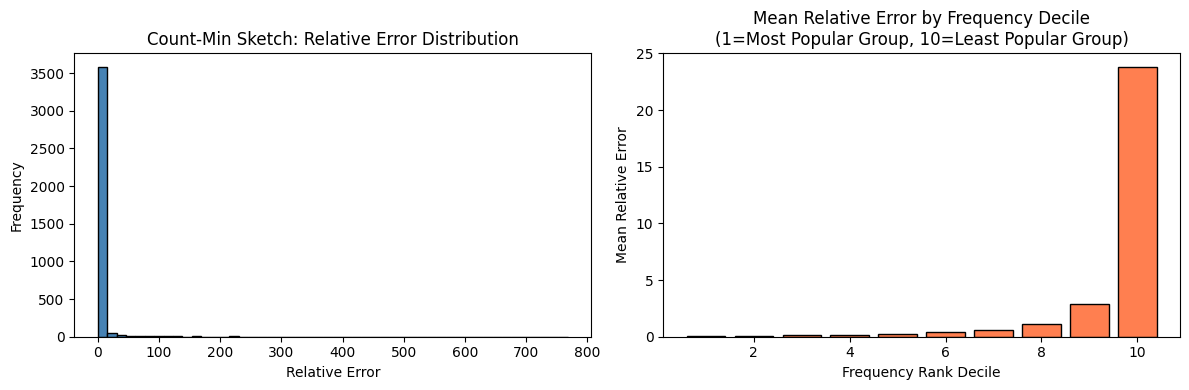

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(relative_errors, bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Count-Min Sketch: Relative Error Distribution") # Count-Min Sketch: 상대 오차 분포
axes[0].set_xlabel("Relative Error") # 상대 오차
axes[0].set_ylabel("Frequency") # 빈도

# 빈도(인기도) 구간별 평균 상대 오차 — 인기 영화 vs 비인기 영화
true_counts_arr = np.array(list(ground_truth_counts.values()))
sort_idx = np.argsort(-true_counts_arr)
sorted_rel_err = relative_errors[sort_idx]

bucket_size = len(sorted_rel_err) // 10
bucket_means = [sorted_rel_err[i*bucket_size:(i+1)*bucket_size].mean() for i in range(10)]

axes[1].bar(range(1, 11), bucket_means, color="coral", edgecolor="black")
axes[1].set_title("Mean Relative Error by Frequency Decile\n(1=Most Popular Group, 10=Least Popular Group)") # 빈도 구간별 평균 상대 오차 (1=가장 인기있는 영화 그룹, 10=가장 비인기 그룹)
axes[1].set_xlabel("Frequency Rank Decile") # 빈도 순위 구간 (10분위)
axes[1].set_ylabel("Mean Relative Error") # 평균 상대 오차

plt.tight_layout()
plt.show()

---
## STEP 05. 메모리 사용량 비교

각 자료구조의 실제 메모리 사용량을 Ground Truth(전체 데이터를 저장하는 `set`/`dict`)와 비교한다.


In [33]:
from pympler import asizeof

# Ground Truth 자료구조 메모리
gt_set_mem = asizeof.asizeof(ground_truth_set)
gt_dict_mem = asizeof.asizeof(ground_truth_counts)

# 스트리밍 알고리즘 메모리
bf_mem = bf.memory_bytes()
cms_mem = cms.memory_bytes()

memory_comparison = pd.DataFrame({
    "자료구조": [
        "Ground Truth set (UserID_MovieID)",
        "Bloom Filter",
        "Ground Truth dict (MovieID 빈도)",
        "Count-Min Sketch"
    ],
    "메모리 (bytes)": [gt_set_mem, bf_mem, gt_dict_mem, cms_mem],
    "메모리 (MB)": [
        round(gt_set_mem / 1024**2, 3),
        round(bf_mem / 1024**2, 3),
        round(gt_dict_mem / 1024**2, 3),
        round(cms_mem / 1024**2, 3)
    ]
})
memory_comparison["압축률 (Ground Truth 대비)"] = [
    "1.0x (기준)",
    f"{gt_set_mem / bf_mem:.1f}x 절약",
    "1.0x (기준)",
    f"{gt_dict_mem / cms_mem:.1f}x 절약"
]

display(memory_comparison)

,자료구조,메모리 (bytes),메모리 (MB),압축률 (Ground Truth 대비)
0,Ground Truth set (UserID_MovieID),88968376,84.847,1.0x (기준)
1,Bloom Filter,1198383,1.143,74.2x 절약
2,Ground Truth dict (MovieID 빈도),328208,0.313,1.0x (기준)
3,Count-Min Sketch,80000,0.076,4.1x 절약


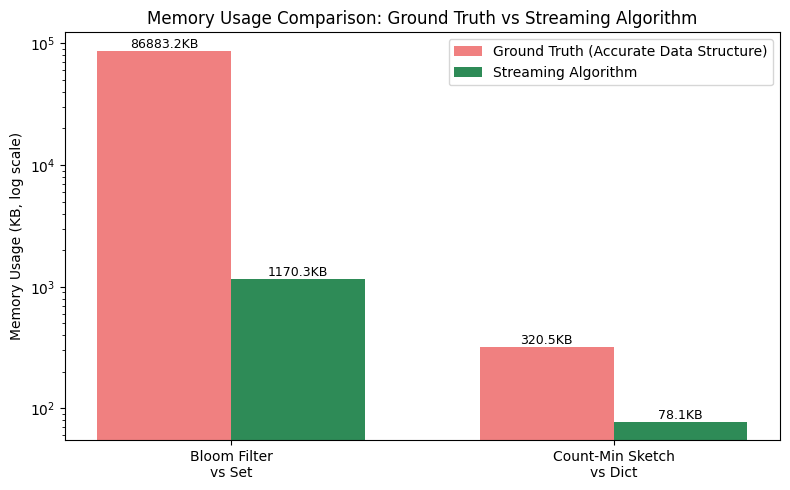

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Bloom Filter\nvs Set", "Count-Min Sketch\nvs Dict"]
streaming_mem = [bf_mem / 1024, cms_mem / 1024]   # KB
ground_truth_mem = [gt_set_mem / 1024, gt_dict_mem / 1024]

x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, ground_truth_mem, width, label="Ground Truth (Accurate Data Structure)", color="lightcoral")
ax.bar(x + width/2, streaming_mem, width, label="Streaming Algorithm", color="seagreen")

ax.set_ylabel("Memory Usage (KB, log scale)")
ax.set_yscale("log")
ax.set_title("Memory Usage Comparison: Ground Truth vs Streaming Algorithm")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i, (gt, st) in enumerate(zip(ground_truth_mem, streaming_mem)):
    ax.text(i - width/2, gt, f"{gt:.1f}KB", ha="center", va="bottom", fontsize=9)
    ax.text(i + width/2, st, f"{st:.1f}KB", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

---
## STEP 06. 처리 시간(Processing Time) 비교

각 알고리즘을 단독으로 스트리밍 처리할 때 걸리는 시간과 처리량(throughput)을 비교한다.


In [35]:
# 알고리즘별 단독 처리 시간 측정
def time_bloom_only(path, n_items, fp_rate):
    bf_local = BloomFilter(n_items=n_items, fp_rate=fp_rate)
    start = time.time()
    with open(path, "r", encoding="ISO-8859-1") as f:
        for line in f:
            uid, mid, rating, ts = line.strip().split("::")
            bf_local.add(f"{uid}_{mid}")
    return time.time() - start

def time_cms_only(path, width, depth):
    cms_local = CountMinSketch(width=width, depth=depth)
    start = time.time()
    with open(path, "r", encoding="ISO-8859-1") as f:
        for line in f:
            uid, mid, rating, ts = line.strip().split("::")
            cms_local.add(mid)
    return time.time() - start

def time_ground_truth_only(path):
    gt_set_local = set()
    gt_dict_local = {}
    start = time.time()
    with open(path, "r", encoding="ISO-8859-1") as f:
        for line in f:
            uid, mid, rating, ts = line.strip().split("::")
            gt_set_local.add(f"{uid}_{mid}")
            gt_dict_local[mid] = gt_dict_local.get(mid, 0) + 1
    return time.time() - start

t_bloom = time_bloom_only(RATINGS_PATH, total_records, bloom_fp_rate)
t_cms = time_cms_only(RATINGS_PATH, cms_width, cms_depth)
t_gt = time_ground_truth_only(RATINGS_PATH)

time_df = pd.DataFrame({
    "처리 방식": ["Bloom Filter (단독)", "Count-Min Sketch (단독)", "Ground Truth (set+dict, 단독)"],
    "처리 시간 (초)": [round(t_bloom, 3), round(t_cms, 3), round(t_gt, 3)],
    "초당 처리량 (records/sec)": [
        round(total_records / t_bloom),
        round(total_records / t_cms),
        round(total_records / t_gt)
    ]
})
display(time_df)

,처리 방식,처리 시간 (초),초당 처리량 (records/sec)
0,Bloom Filter (단독),5.516,181330
1,Count-Min Sketch (단독),1.958,510833
2,"Ground Truth (set+dict, 단독)",0.830,1204425


---
## STEP 07. 파라미터 비교 실험

### 7-1. Bloom Filter — 목표 False Positive Rate(p)에 따른 비트 배열 크기 / 메모리 / 실측 FPR 비교


In [36]:
bloom_param_results = []

for target_fpr in [0.5, 0.1, 0.01, 0.001]:
    bf_p = BloomFilter(n_items=total_records, fp_rate=target_fpr)
    with open(RATINGS_PATH, "r", encoding="ISO-8859-1") as f:
        for line in f:
            uid, mid, rating, ts = line.strip().split("::")
            bf_p.add(f"{uid}_{mid}")

    fp_count = sum(1 for k in test_keys if k in bf_p)
    measured = fp_count / len(test_keys)

    bloom_param_results.append({
        "목표 FP Rate": target_fpr,
        "비트 배열 크기 (m)": bf_p.size,
        "해시 함수 개수 (k)": bf_p.hash_count,
        "메모리 (KB)": round(bf_p.memory_bytes() / 1024, 2),
        "실측 FP Rate": round(measured, 4)
    })

bloom_param_df = pd.DataFrame(bloom_param_results)
display(bloom_param_df)

,목표 FP Rate,비트 배열 크기 (m),해시 함수 개수 (k),메모리 (KB),실측 FP Rate
0,0.500,1442996,1,176.15,0.4992
1,0.100,4793530,3,585.15,0.0978
2,0.010,9587061,7,1170.30,0.0096
3,0.001,14380592,10,1755.44,0.0009


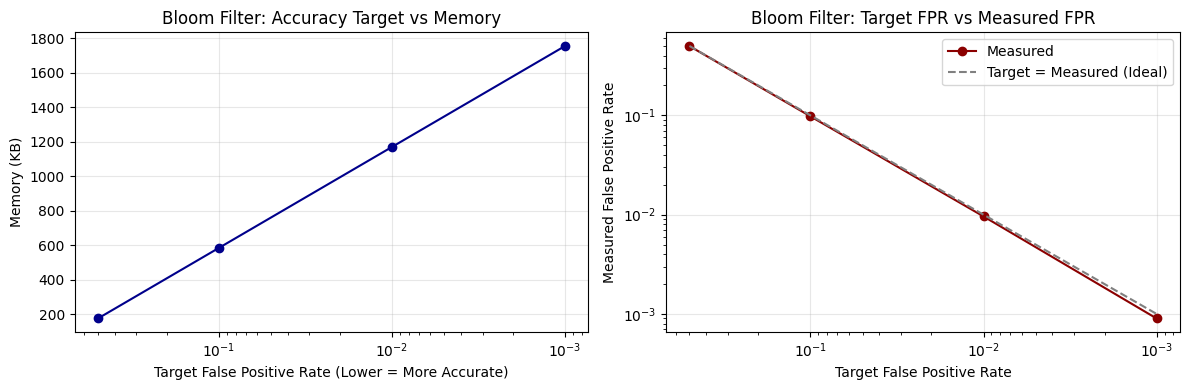

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bloom_param_df["목표 FP Rate"], bloom_param_df["메모리 (KB)"], marker="o", color="darkblue")
axes[0].set_xscale("log")
axes[0].invert_xaxis()
axes[0].set_xlabel("Target False Positive Rate (Lower = More Accurate)")
axes[0].set_ylabel("Memory (KB)")
axes[0].set_title("Bloom Filter: Accuracy Target vs Memory")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bloom_param_df["목표 FP Rate"], bloom_param_df["실측 FP Rate"], marker="o", color="darkred", label="Measured")
axes[1].plot(bloom_param_df["목표 FP Rate"], bloom_param_df["목표 FP Rate"], linestyle="--", color="gray", label="Target = Measured (Ideal)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].invert_xaxis()
axes[1].set_xlabel("Target False Positive Rate")
axes[1].set_ylabel("Measured False Positive Rate")
axes[1].set_title("Bloom Filter: Target FPR vs Measured FPR")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7-2. Count-Min Sketch — width/depth에 따른 정확도 / 메모리 비교


In [38]:
cms_param_configs = [
    (500, 3),
    (1000, 4),
    (2000, 5),
    (5000, 5),
    (10000, 7),
]

cms_param_results = []
for width, depth in cms_param_configs:
    cms_p = CountMinSketch(width=width, depth=depth)
    with open(RATINGS_PATH, "r", encoding="ISO-8859-1") as f:
        for line in f:
            uid, mid, rating, ts = line.strip().split("::")
            cms_p.add(mid)

    rel_errs = []
    for mid, true_count in ground_truth_counts.items():
        est = cms_p.estimate(mid)
        rel_errs.append((est - true_count) / true_count)

    cms_param_results.append({
        "width": width,
        "depth": depth,
        "메모리 (KB)": round(cms_p.memory_bytes() / 1024, 2),
        "평균 상대 오차": round(np.mean(rel_errs), 4),
        "최대 상대 오차": round(np.max(rel_errs), 4)
    })

cms_param_df = pd.DataFrame(cms_param_results)
display(cms_param_df)

,width,depth,메모리 (KB),평균 상대 오차,최대 상대 오차
0,500,3,11.72,69.4892,3125.0000
1,1000,4,31.25,17.6769,1733.0000
2,2000,5,78.12,2.9958,768.0000
3,5000,5,195.31,0.1503,73.0000
4,10000,7,546.88,0.0000,0.0175


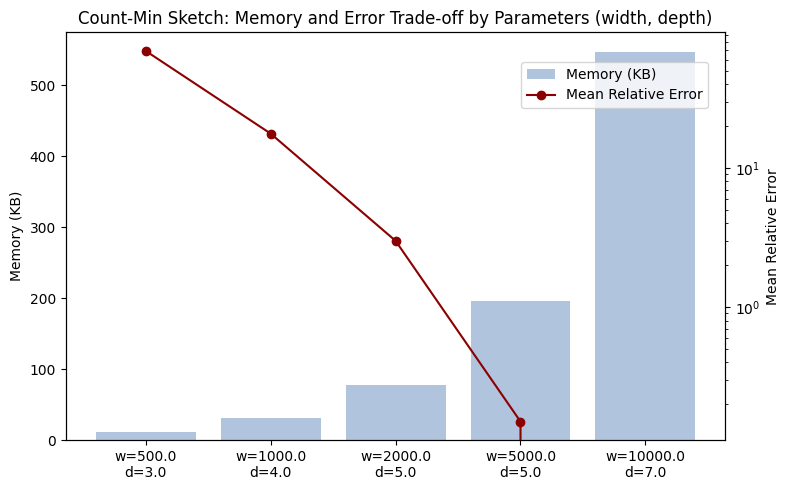

In [39]:
fig, ax1 = plt.subplots(figsize=(8, 5))

x = range(len(cms_param_df))
labels = [f"w={r['width']}\nd={r['depth']}" for _, r in cms_param_df.iterrows()]

ax1.bar(x, cms_param_df["메모리 (KB)"], color="lightsteelblue", label="Memory (KB)")
ax1.set_ylabel("Memory (KB)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
ax2.plot(x, cms_param_df["평균 상대 오차"], color="darkred", marker="o", label="Mean Relative Error")
ax2.set_ylabel("Mean Relative Error")
ax2.set_yscale("log")

ax1.set_title("Count-Min Sketch: Memory and Error Trade-off by Parameters (width, depth)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))

plt.tight_layout()
plt.show()

---
## STEP 08. 알고리즘별 종합 비교 및 장단점 분석

### 종합 결과표


In [40]:
summary_df = pd.DataFrame({
    "알고리즘": ["Bloom Filter", "Count-Min Sketch"],
    "목적": ["원소 포함 여부 근사 판정", "항목별 빈도 근사 추정"],
    "메모리 (KB)": [round(bf_mem/1024, 2), round(cms_mem/1024, 2)],
    "Ground Truth 메모리 (KB)": [round(gt_set_mem/1024, 2), round(gt_dict_mem/1024, 2)],
    "메모리 절감률": [
        f"{(1 - bf_mem/gt_set_mem)*100:.1f}%",
        f"{(1 - cms_mem/gt_dict_mem)*100:.1f}%"
    ],
    "정확도 지표": ["False Positive Rate", "평균 상대 오차"],
    "정확도 측정값": [round(measured_fpr, 4), round(relative_errors.mean(), 4)],
    "처리 시간 (초)": [round(t_bloom, 3), round(t_cms, 3)],
    "오차 방향": ["False Positive만 발생 (FN 없음)", "과대추정만 발생 (과소추정 없음)"]
})
display(summary_df)

,알고리즘,목적,메모리 (KB),Ground Truth 메모리 (KB),메모리 절감률,정확도 지표,정확도 측정값,처리 시간 (초),오차 방향
0,Bloom Filter,원소 포함 여부 근사 판정,1170.30,86883.18,98.7%,False Positive Rate,0.0096,5.516,False Positive만 발생 (FN 없음)
1,Count-Min Sketch,항목별 빈도 근사 추정,78.12,320.52,75.6%,평균 상대 오차,2.9958,1.958,과대추정만 발생 (과소추정 없음)
